# Introduction

## Description
This project describes the transition from the **Black-Scholes** framework to the **Dupire Local Volatility** model. The Black-Scholes model serves for quoting prices via **Implied Volatility (IV)**, but it fails to account for the **"Volatility Smirk"** observed in equity markets like NVDA.

### The Problem:
The Black-Scholes formula assumes *constant volatility* $\sigma$:
$$dS_t = (r-q)S_t dt + \sigma S_t dW_t$$
However, market data shows that $\sigma$ is a function of Strike ($K$) and Expiry ($T$).

### The Solution: Dupire Local Volatility
We derive a state-dependent volatility surface $\sigma_{loc}(S, t)$ that is internally consistent with all observed market prices. By using the Dupire Identity:
$$\sigma_{loc}(K, T)^2 = \frac{\frac{\partial C}{\partial T} + (r - q) K \frac{\partial C}{\partial K} + qC}{\frac{1}{2} K^2 \frac{\partial^2 C}{\partial K^2}}$$
#### Parameters:

* **$\sigma^2_{loc}(K, T)$**: Local variance at strike $K$ and maturity $T$.
* **$C$**: Market price of the European Call option.
* **$K$**: Strike price.
* **$T$**: Time to maturity.
* **$r$**: Risk-free interest rate.
* **$q$**: Continuous dividend yield (important for NVDA).
* **$\frac{\partial C}{\partial T}$**: First derivative of price with respect to maturity (Theta).
* **$\frac{\partial C}{\partial K}$**: First derivative of price with respect to strike.
* **$\frac{\partial^2 C}{\partial K^2}$**: Second derivative of price with respect to strike (Risk-neutral density).

We build a model that captures the dynamic relationship between price action and volatility.

## Plan
1. Prepare data
2. Build implied volatility surface
3. Compute local volatility (Dupire)
4. Price options under both models
5. Compare pricing errors for both models

In [1]:
import sys
import pandas as pd
import numpy as np
from scipy.interpolate import RectBivariateSpline
from scipy.stats import norm

sys.path.append('../src')

from data_loader import load_and_clean_data
from vol_surface import build_volatility_surfaces
from pricing import black_scholes_call, local_vol_monte_carlo
from visualization import plot_vol_smile, plot_volatility_surfaces, plot_volatility_surfaces_plotly

In [2]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [3]:
data_path = "../data/nvda_2020_2022.csv"
fig_dir = "../figures"

# Data preparation

For this project we use the dataset [$NVDA Option Chains - Q1 2020 to Q4 2022](https://www.kaggle.com/datasets/kylegraupe/nvda-daily-option-chains-q1-2020-to-q4-2022).

In [4]:
# Download and unzip the dataset
!curl -L -o ../data/nvda-daily-option-chains-q1-2020-to-q4-2022.zip\
  https://www.kaggle.com/api/v1/datasets/download/kylegraupe/nvda-daily-option-chains-q1-2020-to-q4-2022
!unzip -o ../data/nvda-daily-option-chains-q1-2020-to-q4-2022.zip\
  -d ../data/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 75.3M  100 75.3M    0     0  18.8M      0  0:00:03  0:00:03 --:--:-- 19.9M
Archive:  ../data/nvda-daily-option-chains-q1-2020-to-q4-2022.zip
  inflating: ../data/nvda_2020_2022.csv  


In [5]:
df, snapshot_date = load_and_clean_data(data_path)
df.head()

,strike,expire,T,S,iv,mid
3,120.0,2023-01-13,0.038356,146.13,0.61287,26.700
17,135.0,2023-01-13,0.038356,146.13,0.58963,13.800
22,136.0,2023-01-13,0.038356,146.13,0.58176,13.000
24,137.0,2023-01-13,0.038356,146.13,0.58129,12.300
28,138.0,2023-01-13,0.038356,146.13,0.57756,11.575


# Volatility ''smile''

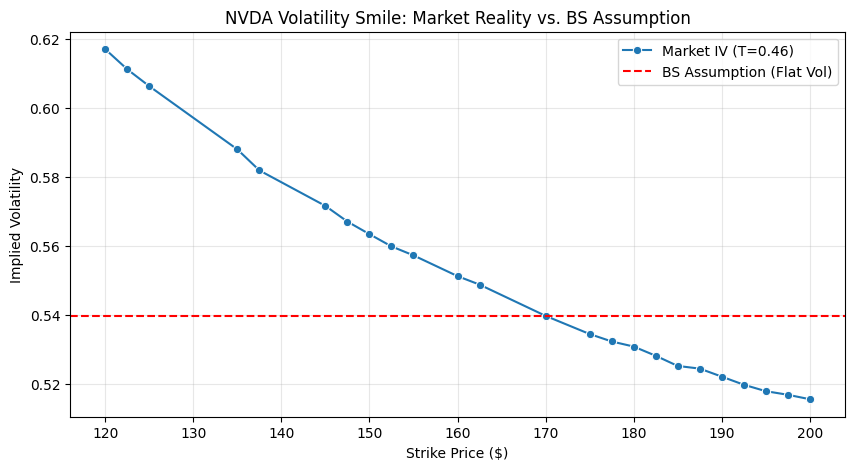

In [6]:
plot_vol_smile(df, target_T=0.5, figures_dir=fig_dir)

# Volatility Surface

In [7]:
K_grid, T_grid, iv_surf, local_vol, spline_model = build_volatility_surfaces(df)

## Static volatility surface graph (`matplotlib`)

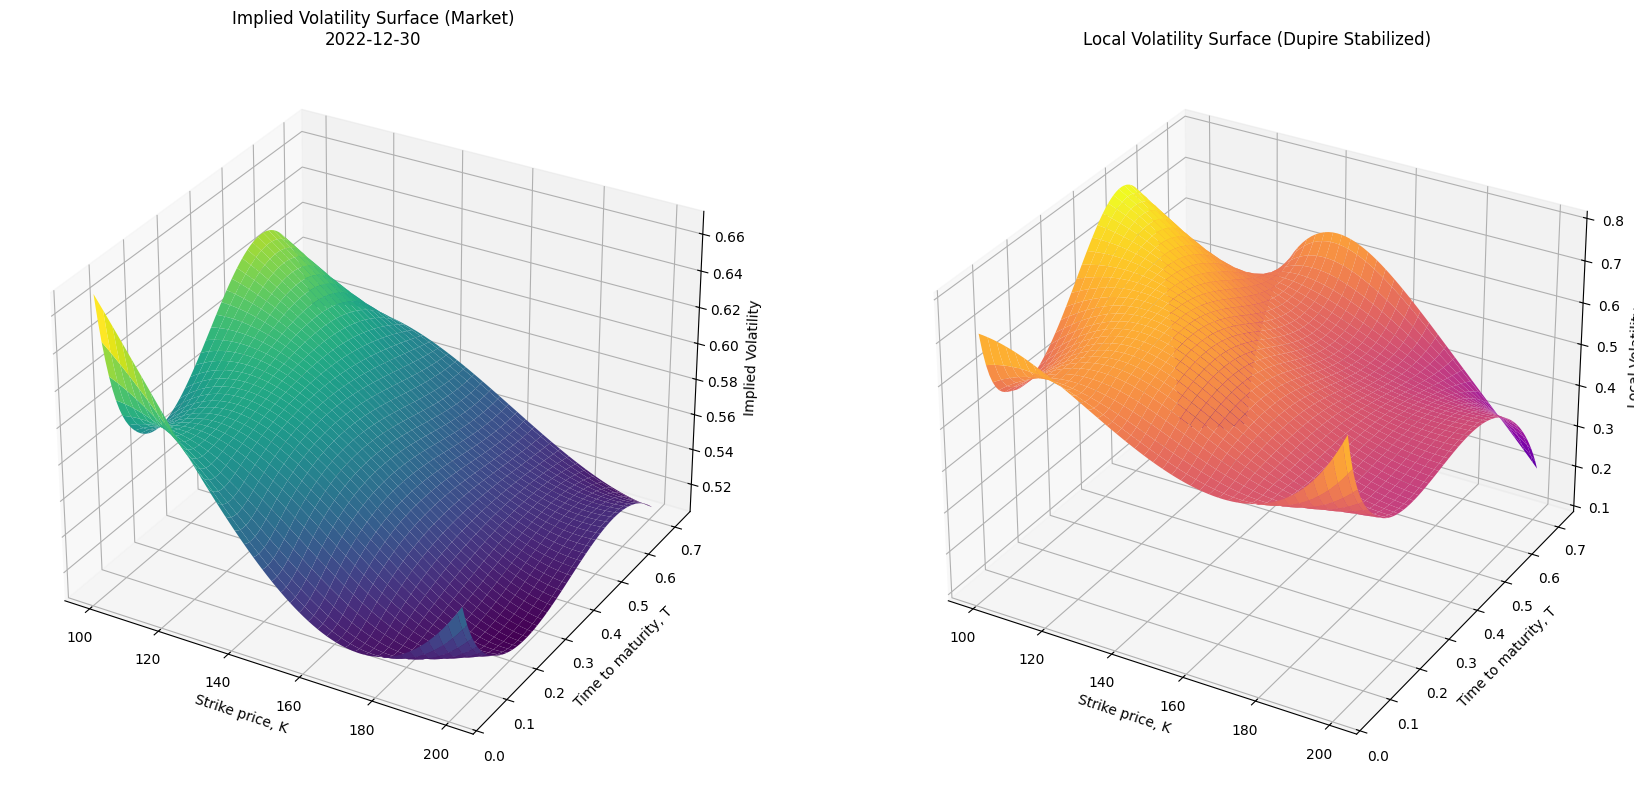

In [8]:
plot_volatility_surfaces(K_grid, T_grid, iv_surf, local_vol, snapshot_date, fig_dir)

## Interactive graph (`plotly`)
*Note*: the graph is **not** interactive when viewed on a static HTML (such as a Github page).

In [9]:
plot_volatility_surfaces_plotly(K_grid, T_grid, iv_surf, local_vol, snapshot_date)

# Model comparison

In [10]:
S_now = df['S'].iloc[0]
r = 0.04
test_T = 0.5 # 6 months out

results = []
for m in [0.9, 1.0, 1.1]:
    K_test = S_now * m
    mkt_iv = float(spline_model(test_T, K_test)[0,0])
    
    # Calculate both prices
    price_bs = black_scholes_call(S_now, K_test, test_T, r, mkt_iv)
    price_lv = local_vol_monte_carlo(S_now, K_test, test_T, r, spline_model)
    
    results.append({
        "Moneyness": m,
        "Strike": round(K_test, 2),
        "Market_IV": round(mkt_iv, 4),
        "BS_Price": round(price_bs, 4),
        "Dupire_Price": round(price_lv, 4),
        "Diff": round(price_lv - price_bs, 4)
    })

comparison_df = pd.DataFrame(results)

print(f"Surface snapshot: {snapshot_date}")
print(comparison_df)

Surface snapshot: 2022-12-30 00:00:00
   Moneyness  Strike  Market_IV  BS_Price  Dupire_Price    Diff
0        0.9  131.52     0.5882   32.2687       32.4186  0.1499
1        1.0  146.13     0.5667   24.4514       23.9393 -0.5120
2        1.1  160.74     0.5475   18.0243       17.7769 -0.2474
